Random_state:  6
              precision    recall  f1-score   support

 non-healing       0.67      0.50      0.57         4
     healing       0.87      0.93      0.90        14

    accuracy                           0.83        18
   macro avg       0.77      0.71      0.73        18
weighted avg       0.82      0.83      0.82        18

Accuracy: 83.33333333333334 %


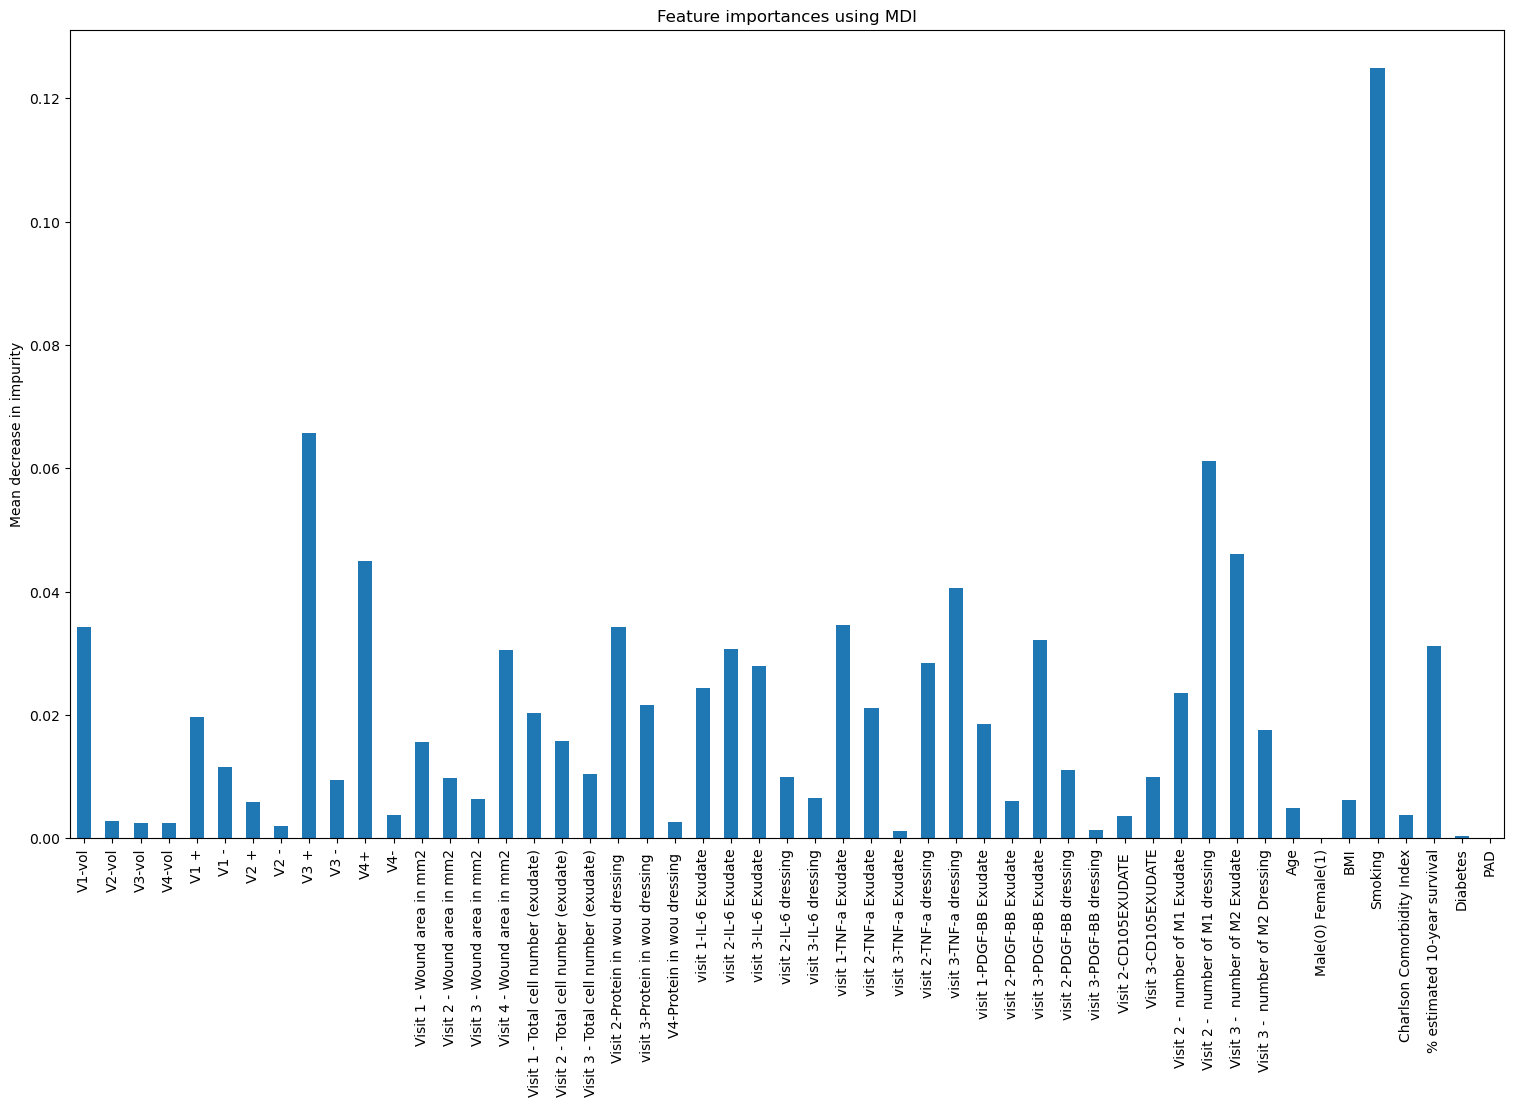

[[ 0.29827738  0.7017226 ]
 [ 0.22256863  0.77743137]
 [ 0.17833525  0.82166475]
 [-0.13710308  1.1371031 ]
 [ 0.34899122  0.6510088 ]
 [ 0.45127213  0.54872787]
 [ 0.46265352  0.5373465 ]
 [ 0.32688212  0.6731179 ]
 [ 0.40415847  0.5958415 ]
 [ 0.43439895  0.56560105]
 [-0.17120469  1.1712047 ]
 [ 0.31476152  0.6852385 ]
 [ 0.20133758  0.7986624 ]
 [ 1.0228832  -0.02288324]
 [ 0.21156466  0.78843534]
 [ 0.60907817  0.39092183]
 [-0.08112609  1.0811261 ]
 [ 0.94775915  0.05224082]]


<Figure size 40000x12000 with 0 Axes>

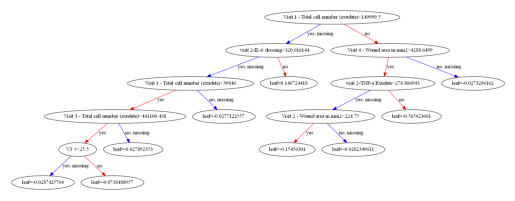

--------------------------------------------------------------------------------------------------


In [142]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import re
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
from dtreeviz import model

Treatment=pd.read_csv("../AD report/full_train.csv")
Treatment_test=pd.read_csv("../AD report/full_test.csv")


X_train=Treatment.iloc[:,1:]
y_train=Treatment.iloc[:,0]


X_test=Treatment_test.iloc[:,1:]
y_test=Treatment_test.iloc[:,0]


#y_train = to_categorical(df_y)
#y_test = to_categorical(df_y_test)

W_tree=1
R_state=random.randrange(1,100)
print("Random_state: ",R_state)
R_state=3



clf=XGBClassifier(booster="dart",
                  normalize_type="forest",
                  tree_method="exact",
                 objective="reg:pseudohubererror",
                  eta=0.6,
                  max_depth=None,
                  subsample=0.7,
                  #colsample_bytree=0.7,
                 #colsample_bylevel=0.7,
                 colsample_bynode=0.6,
                  #reg_lambda=0.1,
                 # reg_alpha=0.4,
                  rate_drop=1,
                  skip_drop=0.7,
                  #one_drop=1,
                 #num_parallel_tree=50,
                 #sample_type="weighted",
                  
                  random_state=R_state,
                  
                  
                  
    )



clf.fit(X_train, y_train,)
#y_pred = clf.predict(X_test)
y_pred = clf.predict(X_test, iteration_range=(0, 100))
y_pred = (y_pred > 0.5) 

print(classification_report(y_test,y_pred,output_dict=False,target_names=["non-healing","healing"]))


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

names=clf.get_booster().feature_names

importances = clf.feature_importances_
forest_importances = pd.Series(importances, index=names)

fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.set_size_inches(18.5, 10.5)
plt.show()

f = open("out.txt", "w")
var=clf.get_booster().get_dump()
for line in var:
    f.write(f"{line}\n")
f.close()

print(clf.predict_proba(X_test))
#print(y_pred)


plt.figure(figsize=(400, 120))
plot_tree(clf, num_trees=W_tree)
plt.show()








print("--------------------------------------------------------------------------------------------------")

target = 'key'
class_names=["non-healing","healing"]


#Which_data=df_y_test
Which_data=y_train

from supertree import SuperTree
st = SuperTree(
    clf, 
    X_train, 
    Which_data, 
    names, 
    class_names
)
# Visualize the tree
st.show_tree(which_tree=W_tree)